Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Read the CSV File

In [ ]:
df = pd.read_csv("Titanic.csv")

Handling missing values

In [ ]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,1,3,Allison Hill,male,17,4,2,43d75413-a939-4bd1-a516-b0d47d3572cc,144.08,Q,1
1,2,1,Noah Rhodes,male,60,2,2,6334fa2a-8b4b-47e7-a451-5ae01754bf08,249.04,S,0
2,3,3,Angie Henderson,male,64,0,0,61a66444-e2af-4629-9efb-336e2f546033,50.31,Q,1
3,4,3,Daniel Wagner,male,35,4,0,0b6c03c8-721e-4419-afc3-e6495e911b91,235.20,C,1
4,5,1,Cristian Santos,female,70,0,3,436e3c49-770e-49db-b092-d40143675d58,160.17,C,1


In [ ]:
df.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
995,996,2,Brittany Ward,male,69,2,3,75eb0e8f-a090-460d-a7c7-655a7b434a72,19.87,Q,1
996,997,2,Edward Stanley,female,61,4,4,e55b93ad-8976-4471-9d7f-57d1e45def26,85.35,C,0
997,998,3,Christina Johnson,male,10,4,1,d06d3943-c8b3-415e-b664-704355c9bf0f,444.22,C,0
998,999,3,Edgar Miller,male,50,3,2,0e5779ec-be1a-470f-ad83-a4c869f8d3e4,234.67,S,1
999,1000,1,Elizabeth Sanders,male,3,3,3,90a014ab-4ca1-4abd-8565-0e0bd5c97d5d,286.65,C,1


In [ ]:
df.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
273,274,2,Shelly Alexander,male,47,3,3,505c7527-dc57-446d-8c3d-031ab3952193,118.41,C,0
382,383,1,Douglas Gregory,female,70,3,2,1d57e734-31bf-4cf6-80b3-af7cd5b211a9,93.76,Q,1
737,738,1,Arthur Hamilton MD,female,65,1,4,637b3648-d617-49c0-a449-d64f922ddab6,454.93,Q,0
812,813,2,Douglas Ryan,female,64,4,3,86351a54-bc54-48c1-bf40-8dcc9db1f7f9,90.05,Q,0
860,861,2,Vanessa Hatfield,male,47,1,0,6491982b-e5ad-481d-977f-4c1626d658fb,213.57,Q,0


In [ ]:
df.size

11000

In [ ]:
df.shape

(1000, 11)

In [ ]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Survived'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1000 non-null   int64  
 1   Pclass       1000 non-null   int64  
 2   Name         1000 non-null   object 
 3   Sex          1000 non-null   object 
 4   Age          1000 non-null   int64  
 5   SibSp        1000 non-null   int64  
 6   Parch        1000 non-null   int64  
 7   Ticket       1000 non-null   object 
 8   Fare         1000 non-null   float64
 9   Embarked     1000 non-null   object 
 10  Survived     1000 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1.964000,38.458000,2.032000,2.005000,247.968650,0.492000
std,288.819436,0.820596,23.103723,1.424431,1.410306,139.301211,0.500186
min,1.000000,1.000000,1.000000,0.000000,0.000000,10.020000,0.000000
25%,250.750000,1.000000,19.000000,1.000000,1.000000,126.295000,0.000000
50%,500.500000,2.000000,36.500000,2.000000,2.000000,246.500000,0.000000
75%,750.250000,3.000000,59.000000,3.000000,3.000000,365.662500,1.000000
max,1000.000000,3.000000,79.000000,4.000000,4.000000,499.780000,1.000000


Check Missing Values

In [ ]:
print(df.isnull().sum())

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Survived       0
dtype: int64


Remove Duplicate Records

In [ ]:
print(df.duplicated().sum())

0


Identify Outliers

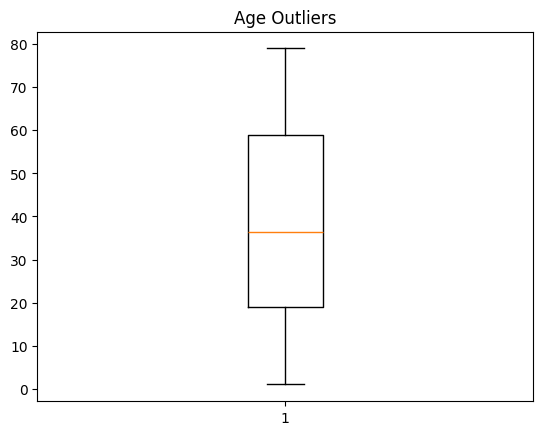

In [ ]:
plt.boxplot(df["Age"])
plt.title("Age Outliers")
plt.show()

Treat Outliers Using IQR

In [ ]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Age"] >= lower) & (df["Age"] <= upper)]

Filter Passengers

In [ ]:
adults = df[df["Age"] > 18]
adults

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
1,2,1,Noah Rhodes,male,60,2,2,6334fa2a-8b4b-47e7-a451-5ae01754bf08,249.04,S,0
2,3,3,Angie Henderson,male,64,0,0,61a66444-e2af-4629-9efb-336e2f546033,50.31,Q,1
3,4,3,Daniel Wagner,male,35,4,0,0b6c03c8-721e-4419-afc3-e6495e911b91,235.20,C,1
4,5,1,Cristian Santos,female,70,0,3,436e3c49-770e-49db-b092-d40143675d58,160.17,C,1
5,6,1,Connie Lawrence,male,30,2,3,907276ea-44c0-4a9a-964a-cb1f39eb038a,412.97,Q,1
...,...,...,...,...,...,...,...,...,...,...,...
991,992,3,Brian Harris,female,78,1,3,31ab0158-2cf6-473b-9500-c14707743c94,328.20,C,1
992,993,2,Michael Bowen,male,75,2,1,ec1a86d3-5683-4783-9575-9337549c9eb9,337.75,S,0
995,996,2,Brittany Ward,male,69,2,3,75eb0e8f-a090-460d-a7c7-655a7b434a72,19.87,Q,1
996,997,2,Edward Stanley,female,61,4,4,e55b93ad-8976-4471-9d7f-57d1e45def26,85.35,C,0


In [ ]:
female = df[df["Sex"] == "female"]
female

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
4,5,1,Cristian Santos,female,70,0,3,436e3c49-770e-49db-b092-d40143675d58,160.17,C,1
6,7,3,Abigail Shaffer,female,71,4,0,b24beb96-c092-4b74-a6b0-7ff60fc79913,37.92,C,1
7,8,2,Gina Moore,female,74,2,0,ab0b4cc5-15f0-4a19-98c1-80d2aadf3692,215.12,Q,0
9,10,3,Ryan Munoz,female,28,2,1,3a3e46b0-96f8-4ff7-81a7-2883f8802878,365.25,S,1
10,11,3,Monica Herrera,female,60,1,0,6319629b-d73e-4bb9-8f9c-a17b8db8dadf,291.40,C,0
...,...,...,...,...,...,...,...,...,...,...,...
988,989,1,Anna Wheeler,female,15,0,3,1d2467e2-0191-419d-845c-3fbb52ecac27,206.15,S,1
991,992,3,Brian Harris,female,78,1,3,31ab0158-2cf6-473b-9500-c14707743c94,328.20,C,1
993,994,3,Deborah Campbell,female,9,4,1,7978dc84-ea89-4979-baa6-d6eaac273009,401.34,Q,1
994,995,2,Anthony Armstrong,female,16,2,2,22c0c475-a549-46d0-891a-5875cc18dd0e,467.05,C,1


In [ ]:
first = df[df["Pclass"] == 1]
first

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
1,2,1,Noah Rhodes,male,60,2,2,6334fa2a-8b4b-47e7-a451-5ae01754bf08,249.04,S,0
4,5,1,Cristian Santos,female,70,0,3,436e3c49-770e-49db-b092-d40143675d58,160.17,C,1
5,6,1,Connie Lawrence,male,30,2,3,907276ea-44c0-4a9a-964a-cb1f39eb038a,412.97,Q,1
12,13,1,Lisa Hensley,female,37,1,4,efb56207-ddec-440b-afe3-af13891778e8,390.75,S,1
15,16,1,Brian Ramirez,male,20,4,0,08e3f771-b6dc-4d05-9a9b-ccc1e71c681a,273.63,Q,1
...,...,...,...,...,...,...,...,...,...,...,...
984,985,1,Carla Jones,male,70,2,0,365bc763-a333-4ea8-8e58-de208f7763e0,94.20,C,1
985,986,1,Elizabeth Flores,female,4,1,3,b0a4f557-3381-401f-a3ff-8fd202e460aa,263.86,C,0
986,987,1,Angela Jackson,female,20,3,4,115db44f-ca4a-40bc-8121-81a34818b004,114.86,Q,0
988,989,1,Anna Wheeler,female,15,0,3,1d2467e2-0191-419d-845c-3fbb52ecac27,206.15,S,1


In [ ]:
female_first = df[(df["Sex"]=="female") & (df["Pclass"]==1)]
female_first

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
4,5,1,Cristian Santos,female,70,0,3,436e3c49-770e-49db-b092-d40143675d58,160.17,C,1
12,13,1,Lisa Hensley,female,37,1,4,efb56207-ddec-440b-afe3-af13891778e8,390.75,S,1
20,21,1,Margaret Hawkins DDS,female,22,1,1,363e6ef4-f8df-4c3a-aacb-4fbdfbff8a7d,105.63,C,1
21,22,1,Patty Perez,female,17,4,4,0aeccec7-204d-49da-b156-7f2acef74829,249.80,Q,1
25,26,1,Judy Baker,female,50,1,1,ba236c22-e92a-4b97-91db-1a374204d733,420.73,Q,0
...,...,...,...,...,...,...,...,...,...,...,...
951,952,1,Sarah Thompson,female,58,4,0,253741e4-0966-4d08-9959-5d27a73d2746,21.73,C,0
963,964,1,Tom Foster,female,63,2,1,109efb40-8ceb-4c57-97e3-23cf6d651847,21.06,Q,1
985,986,1,Elizabeth Flores,female,4,1,3,b0a4f557-3381-401f-a3ff-8fd202e460aa,263.86,C,0
986,987,1,Angela Jackson,female,20,3,4,115db44f-ca4a-40bc-8121-81a34818b004,114.86,Q,0


In [ ]:
df.sort_values(by="Age")

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
71,72,2,Whitney Peters,female,1,4,1,1723ecdb-b058-4256-94b3-e8cfbfbbeab3,436.63,S,1
476,477,1,Robin Brown,male,1,4,4,8a0ea57a-9a7d-409d-a6e8-790b215d3b1f,49.80,S,0
358,359,2,Christian Leblanc,male,1,0,3,1e494952-ac5d-4e57-a3b6-64f40452f779,483.22,S,1
792,793,1,Maria Cooke,female,1,3,1,6f2e92b9-d130-42db-a13a-14ca5911f42e,414.71,Q,1
338,339,1,Scott Thomas,male,1,0,0,c53f1db3-d275-4d43-8451-7303e94d4fbe,368.43,Q,1
...,...,...,...,...,...,...,...,...,...,...,...
876,877,1,Michael Miles,female,79,3,4,d6eaf269-514e-4353-af23-7c4d1e4ea133,242.79,Q,1
300,301,3,Tanner Mitchell DDS,male,79,2,0,c9c1ad45-f4ea-4b97-aaa4-15b56336c815,183.79,S,1
91,92,1,Brian Rodriguez,female,79,3,1,7b53359e-1bac-4d0d-af35-b30b4c68eb17,220.69,C,0
138,139,3,David Alvarez,female,79,1,3,bb0c7919-330c-4ff5-88a5-fa0d09a85dc5,179.09,S,0


Sort Data

In [ ]:
df.sort_values(by="Fare", ascending=False)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
93,94,3,Christina Walters,male,46,0,1,46e1ee40-dc8a-46a7-933c-2ed5a3fe0479,499.78,C,0
700,701,3,Joseph Ochoa,female,56,2,0,f80590f0-0249-4a09-be3b-1a40ca0553a2,498.90,C,0
906,907,2,Michelle Davis DVM,male,64,4,0,1bfc270c-8549-4255-89db-ebb5c9739495,498.30,S,1
619,620,3,Elizabeth Mendez,female,62,3,1,9afa8267-4479-4214-b5de-f8074a965478,497.83,S,1
477,478,2,Judith Carter,male,44,0,3,f00f63ef-e59f-41c2-804e-a81ad3d877a8,496.37,Q,0
...,...,...,...,...,...,...,...,...,...,...,...
356,357,1,Jesse Perry,male,68,3,2,737cf8b5-6356-4add-a85a-9f2b4236c0bf,13.13,Q,1
855,856,2,Melissa Abbott,male,46,3,4,469ff562-8052-4405-ba84-bb5ffa6e3743,12.05,Q,0
573,574,1,Nancy Brown,female,30,2,4,6c5540f0-cc9c-441c-8696-99010ddca788,10.54,S,0
70,71,3,Jordan Henderson,female,3,0,4,42378962-e4fd-4c34-9670-7a2129dc073e,10.32,C,0


Group Data Using groupby()

In [ ]:
df.groupby("Pclass")["Age"].mean()

,Age
Pclass,
1,38.845070
2,37.855828
3,38.642633


In [ ]:
df.groupby("Sex")["Survived"].sum()

,Survived
Sex,
female,229
male,263


In [ ]:
df.groupby("Pclass")["Fare"].mean()

,Fare
Pclass,
1,235.841099
2,256.533405
3,252.712132


In [ ]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.481690
2,0.484663
3,0.510972


Calculate Survival Statistics

In [ ]:
survival_rate = df["Survived"].mean() * 100
print("Overall Survival Rate:", survival_rate)

Overall Survival Rate: 49.2


In [ ]:
print(df["Survived"].sum())

492


In [ ]:
print((df["Survived"] == 0).sum())

508


In [ ]:
print(df[df["Sex"]=="male"]["Survived"].mean()*100)

49.905123339658445


In [ ]:
print(df[df["Sex"]=="female"]["Survived"].mean()*100)

48.41437632135307


In [ ]:
print(df.groupby("Pclass")["Survived"].mean()*100)

Pclass
1    48.169014
2    48.466258
3    51.097179
Name: Survived, dtype: float64


Create Visualizations

Bar chart

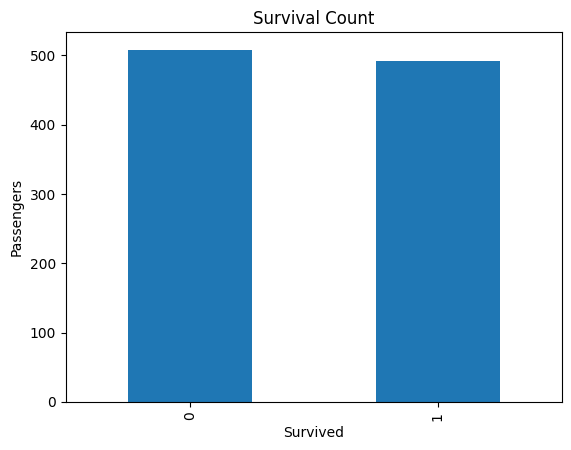

In [ ]:
df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Passengers")
plt.show()

Histogram

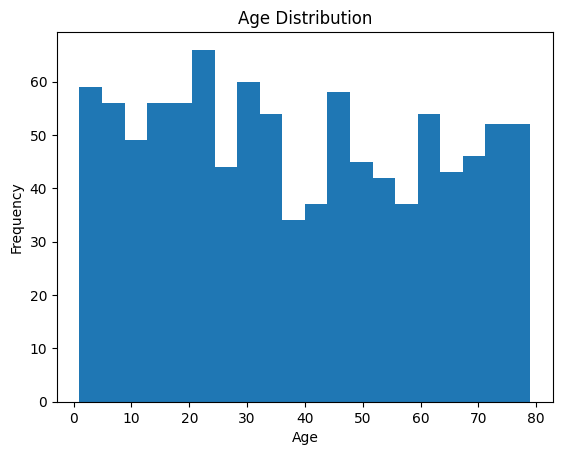

In [ ]:
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Line chart

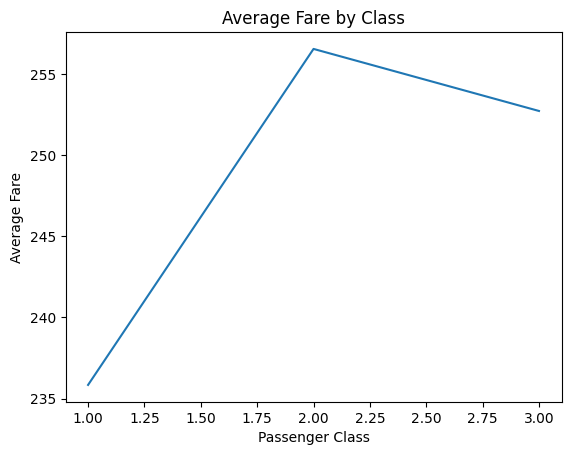

In [ ]:
df.groupby("Pclass")["Fare"].mean().plot(kind="line")

plt.title("Average Fare by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.show()

Scatter plot

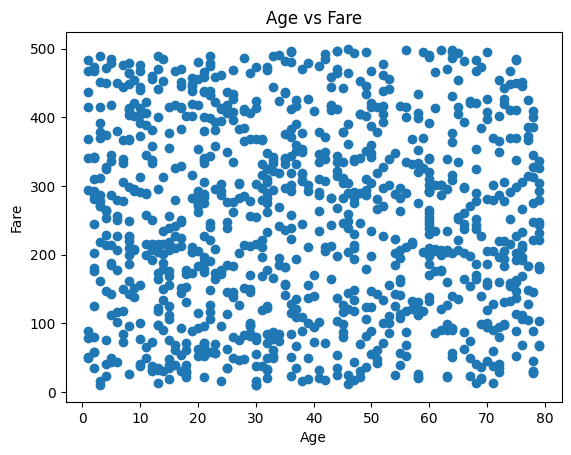

In [ ]:
plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

Save the Cleaned Dataset

In [ ]:
df.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
